In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [83]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [84]:
df.shape

(2640, 12)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [86]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [87]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Data Preprocessing

In [88]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()

df_ml['Region'] = le_region.fit_transform(df_ml['Region'])
df_ml['Model'] = le_model.fit_transform(df_ml['Model'])

df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Regression Modeling

In [89]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Avg_Price_USD", axis=1)
y = df_ml["Avg_Price_USD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


In [90]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Avg_Price_USD", axis=1)
y = df_ml["Avg_Price_USD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
X_train.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2387,2022,2,3,0,10571,11285,60,346,548.63,Estimated (Region),10938
1187,2019,1,3,4,5590,6229,75,419,351.33,Interpolated (Month),11000
2396,2016,1,0,4,10480,10885,82,486,763.99,Interpolated (Month),11726
440,2020,1,1,3,12267,13257,82,460,846.42,Estimated (Region),11937
508,2024,4,1,4,15319,17286,60,350,804.25,Official (Quarter),7906


In [92]:
df_ml.select_dtypes(include='object').columns

Index(['Source_Type'], dtype='object')

In [93]:
from sklearn.preprocessing import LabelEncoder

le_source = LabelEncoder()
df_ml['Source_Type'] = le_source.fit_transform(df_ml['Source_Type'])

In [94]:
df_ml.select_dtypes(include='object').columns

Index([], dtype='object')

In [95]:
X = df_ml.drop("Avg_Price_USD", axis=1)
y = df_ml["Avg_Price_USD"]

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [97]:
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 16770.903585517593
RMSE: 19459.72173840161
R2 Score: -0.004157998769832361


In [98]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, ridge_pred))

R2 Score: -0.004157774079029952


In [99]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, lasso_pred))

R2 Score: -0.004157823811947514


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.120e+11, tolerance: 8.694e+07
  model = cd_fast.enet_coordinate_descent(


In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Alpha: {'alpha': 100}
Best Score: -0.008191311206925844


In [101]:
df_ts = df.copy()

df_ts['Date'] = pd.to_datetime(
    df_ts['Year'].astype(str) + '-' +
    df_ts['Month'].astype(str) + '-01'
)

monthly_sales = df_ts.groupby('Date')['Estimated_Deliveries'].sum()

monthly_sales.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

In [102]:
import matplotlib.pyplot as plt

In [103]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    monthly_sales,
    trend='add'
)

fit = model.fit()

forecast = fit.forecast(12)

print(forecast)

2026-01-01    199247.808646
2026-02-01    199352.936079
2026-03-01    199458.063512
2026-04-01    199563.190945
2026-05-01    199668.318378
2026-06-01    199773.445811
2026-07-01    199878.573243
2026-08-01    199983.700676
2026-09-01    200088.828109
2026-10-01    200193.955542
2026-11-01    200299.082975
2026-12-01    200404.210408
Freq: MS, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


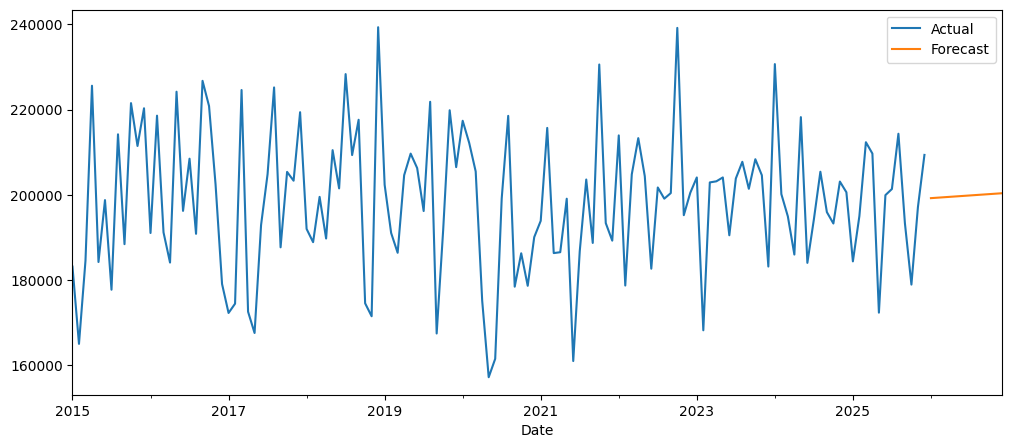

In [104]:
monthly_sales.plot(figsize=(12,5), label='Actual')
forecast.plot(label='Forecast')

plt.legend()
plt.show()

In [105]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    monthly_sales,
    trend='add'
)

fit = model.fit()

forecast = fit.forecast(12)

print(forecast)

2026-01-01    199247.808646
2026-02-01    199352.936079
2026-03-01    199458.063512
2026-04-01    199563.190945
2026-05-01    199668.318378
2026-06-01    199773.445811
2026-07-01    199878.573243
2026-08-01    199983.700676
2026-09-01    200088.828109
2026-10-01    200193.955542
2026-11-01    200299.082975
2026-12-01    200404.210408
Freq: MS, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


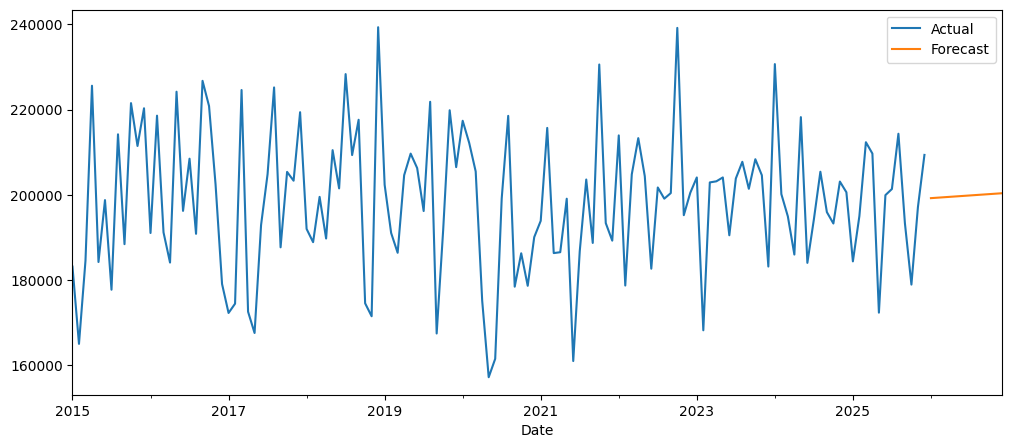

In [106]:
plt.figure(figsize=(12,5))

monthly_sales.plot(label='Actual')
forecast.plot(label='Forecast')

plt.legend()
plt.show()

## Conclusion

- Dataset was preprocessed and categorical features were encoded.
- Linear Regression, Ridge Regression, and Lasso Regression models were trained.
- Model performance was evaluated using MAE, RMSE, and R² Score.
- Hyperparameter tuning was performed using GridSearchCV.
- Time series forecasting was implemented using Exponential Smoothing.
- Future Tesla deliveries were forecasted and visualized.